In [14]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import collections
np.random.seed(0)  

In [ ]:
dataset='euro'

To load the testing data
==========================

In [1]:
if dataset=='euro':
    scaled_data_usd_euro = (data-np.min(data))/(np.max(data)-np.min(data))#scaler.fit_transform(data.reshape(-1,1))

    scaled_data = np.zeros((376,6))
    for t in range(4,380):
        idx = t-4 # row index. We have 1000 rows (0-999)
        scaled_data[idx,:] = [scaled_data_usd_euro[t-4],scaled_data_usd_euro[t-3],scaled_data_usd_euro[t-2],
                                scaled_data_usd_euro[t-1],scaled_data_usd_euro[t],scaled_data_usd_euro[t+1]]
        # We use the first 300 points to train the model and the rest 
        # for the testing phase:
    scaled_data_train = scaled_data[0:300,0:6]
    scaled_data_test = scaled_data[300:,0:6]
    X_train = scaled_data_train[:,:5]  
    Y_train = scaled_data_train[:,5]
    X_test = scaled_data_test[:,:5]  
    Y_test = scaled_data_test[:,5] 
elif dataset=='mackey':
    
    data = mackey_glass(sample_len=1024,seed=0)[0]
    scaled_data_mackey_glass = (data-np.min(data))/(np.max(data)-np.min(data)) #scaler.fit_transform(data)
    scaled_data = np.zeros((1000,5))
    for t in range(18,1018):
        idx = t-18 # row index. We have 1000 rows (0-999)
        scaled_data[idx,:] = [scaled_data_mackey_glass[t-18], scaled_data_mackey_glass[t-12],
                                scaled_data_mackey_glass[t-6], scaled_data_mackey_glass[t],
                                scaled_data_mackey_glass[t+6]]
    # We use the first 500 points to train the model and the rest 
    # for the testing phase:
    scaled_data_train = scaled_data[0:750,0:5]
    scaled_data_test = scaled_data[750:,0:5]
    X_train = scaled_data_train[:,:4]  
    Y_train = scaled_data_train[:,4]
    X_test = scaled_data_test[:,:4]  
    Y_test = scaled_data_test[:,4]
elif dataset=='legendre3':
    x_values = np.linspace(0, 100, 1000)
    # Calculate the third Legendre polynomial without noise
    legendre_poly = 1/8 * (3 * np.cos(x_values) - 5*np.cos(3*x_values))
    # Add seeded random noise to the polynomial
    noise = np.random.normal(0, 0.1, size=len(x_values))
    legendre_poly_with_noise = legendre_poly + noise
    # Store the points in a NumPy array
    data = np.squeeze(np.column_stack((legendre_poly_with_noise)))
    scaled_data_legendre = (data-np.min(data))/(np.max(data)-np.min(data))#scaler.fit_transform(data.reshape(-1,1))
    scaled_data = np.zeros((996,6))
    for t in range(4,999):
        idx = t-4 # row index. We have 1000 rows (0-999)
        scaled_data[idx,:] = [scaled_data_legendre[t-4],scaled_data_legendre[t-3],scaled_data_legendre[t-2],
                                scaled_data_legendre[t-1],scaled_data_legendre[t],scaled_data_legendre[t+1]]
    # We use the first 300 points to train the model and the rest 
    # for the testing phase:
    scaled_data_train = scaled_data[0:750,0:6]
    scaled_data_test = scaled_data[750:,0:6]
    X_train = scaled_data_train[:,:5]  
    Y_train = scaled_data_train[:,5]
    X_test = scaled_data_test[:,:5]  
    Y_test = scaled_data_test[:,5]
    Y_test =   Y_test*(np.max(data)-np.min(data))+np.min(data)
    Y_test=torch.load('actual_targets_qcnn_mg_test.pt')
    Y_test=Y_test[250:]


SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (3573149247.py, line 35)

In [16]:
print(actual_forecasted1_LX.shape)

Y_test=Y_test.reshape((250,))
print(Y_test.shape)

(250,)
(250,)


In [17]:
y_pred=actual_forecasted1_LX
y_true=Y_test


N=y_pred.shape[0]
print("N=", N)
from sklearn.metrics import mean_absolute_error

RMSE = np.sqrt(np.sum(np.square(y_pred-y_true))/N)
print("RMSE=",RMSE)

mae = mean_absolute_error(y_true, y_pred)

print("MAE=",mae)

MAPE = np.sum(np.absolute(y_true-y_pred)/np.absolute(y_true))/N
print("MAPE=",MAPE)

N= 250
RMSE= 0.08678342247023445
MAE= 0.07109310989726442
MAPE= 0.08079239835923241


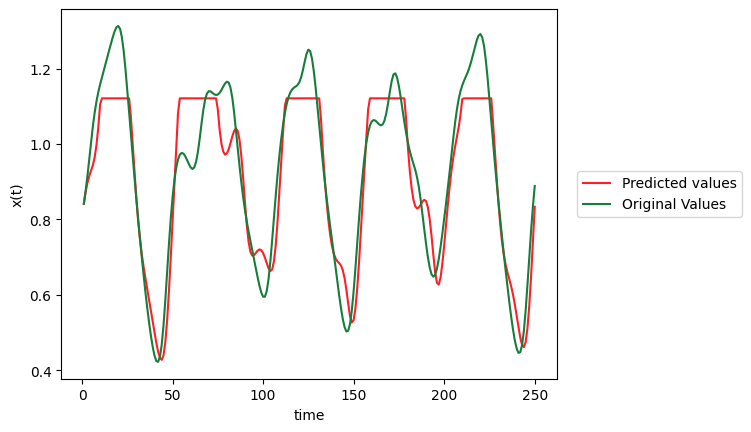

In [18]:
#plt.fig(dpi=300)
n_points=N
plt.plot(np.arange(1,n_points+1), actual_forecasted1_LX, '#ff1f28', label='Predicted values')
plt.plot(np.arange(1,n_points+1), y_true,'#167d3a', label='Original Values')
plt.ylabel('x(t)')
plt.xlabel('time')
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
#plt.title('Box Jenkins Training Phase')
plt.show()

In [19]:
n_points = 500
actual_forecasted2_LX=torch.load('actual_forecasted_test_x.pt')
actual_targets2_LX=torch.load('actual_targets_test_x.pt')

FileNotFoundError: [Errno 2] No such file or directory: 'actual_forecasted_test_x.pt'

In [ ]:
y_pred=actual_forecasted2_LX
y_true=actual_targets2_LX

N=y_pred.shape[0]
print("N=", N)
from sklearn.metrics import mean_absolute_error

RMSE = np.sqrt(np.sum(np.square(y_pred-y_true))/N)
print("RMSE=",round(RMSE,5))

mae = mean_absolute_error(y_true, y_pred)
mae=round(mae,5)
print("MAE=",mae)

MAPE = np.sum(np.absolute(y_true-y_pred)/np.absolute(y_true))/N
print("MAPE=",round(MAPE,5))

N= 500
RMSE= 1.17849
MAE= 0.816
MAPE= 0.32049


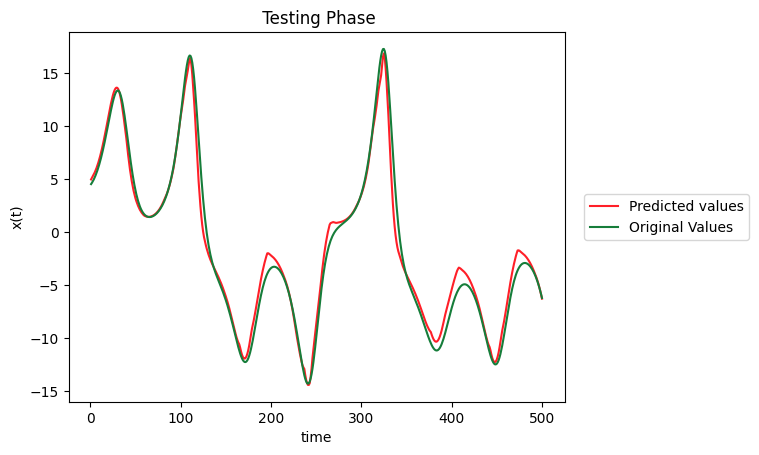

In [ ]:
plt.plot(np.arange(1,n_points+1), actual_forecasted2_LX, '#ff1f28', label='Predicted values')
plt.fig(dpi=300)
plt.plot(np.arange(1,n_points+1), actual_targets2_LX,'#167d3a', label='Original Values')
plt.ylabel('x(t)')
plt.xlabel('time')
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.title(' Testing Phase')
plt.show()

In [ ]:
total_forecasted=np.concatenate((actual_forecasted1_LX, actual_forecasted2_LX), axis=0)
total_forecasted.shape

(1000, 1)

In [ ]:
total_targets=np.concatenate((actual_targets1_LX, actual_targets2_LX), axis=0)
total_targets.shape

(1000, 1)

In [ ]:
total_points=1000

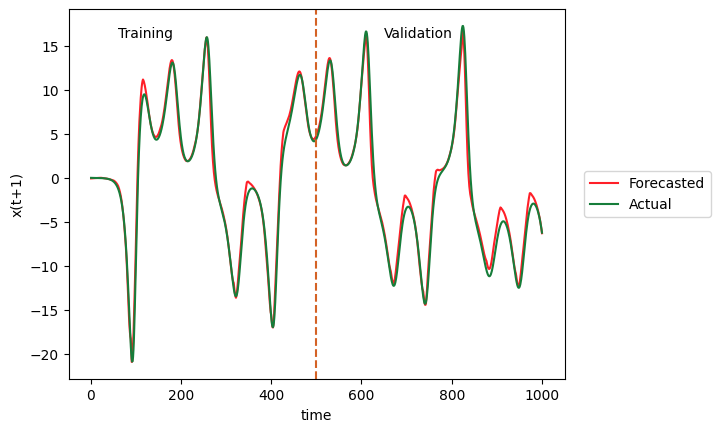

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()
plt.fig(dpi=300)
plt.plot(np.arange(1,total_points+1), total_forecasted, '#ff1f28', label='Forecasted')
plt.plot(np.arange(1,total_points+1), total_targets,'#167d3a', label='Actual')
plt.axvline(x=500,color = '#d46225', linestyle = 'dashed')
ax.text(60, 16, 'Training', fontsize=10)
ax.text(650,16 , 'Validation', fontsize=10)
#ax.text(0, 2, 'Training')

plt.ylabel('x(t+1)')
plt.xlabel('time')
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
#plt.title('Exchange rate USD/EURO')
plt.show()